In [1]:
from itertools import combinations
from pathlib import Path

import krippendorff
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import spearmanr
from sklearn.metrics import cohen_kappa_score

# EMNLP / ACL-style figures: Times-like serif (Option A, no LaTeX required)
EMNLP_RC = {
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "Times",
        "Nimbus Roman No9 L",
        "TeX Gyre Termes",
        "DejaVu Serif",
    ],
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}
plt.rcParams.update(EMNLP_RC)
sns.set_theme(style="whitegrid", context="paper", font="serif")

METHODS = [
    "LAT",
    "PCA",
    "GemmaScopeSAE",
    "DiffMean",
    "LoRA",
    "LoReFT",
    "PromptSteering",
    "DPO",
]
JUDGES = ["anthropic", "google", "openai"]
JUDGE_LABELS = {"anthropic": "Anthropic", "google": "Google", "openai": "OpenAI"}

import matplotlib.colors as mcolors


def _darken_rgb(rgb, factor=0.72):
    return tuple(max(0.0, min(1.0, c * factor)) for c in rgb[:3])


def darken_palette(palette, factor=0.72):
    return [_darken_rgb(c, factor) for c in palette]


def darker_cmap(name: str, start: float = 0.35):
    """Skip the light end of a colormap for darker heatmap fills."""
    base = plt.colormaps[name]
    return mcolors.LinearSegmentedColormap.from_list(
        f"{name}_dark", base(np.linspace(start, 1.0, 256))
    )


JUDGE_PALETTE_LIST = darken_palette(sns.color_palette("Set2", len(JUDGES)), 0.75)
JUDGE_PALETTE_DISPLAY = {
    JUDGE_LABELS[j]: JUDGE_PALETTE_LIST[i] for i, j in enumerate(JUDGES)
}
METHOD_PALETTE = darken_palette(sns.color_palette("icefire", len(METHODS)), 0.82)
METRIC_COLORS = ["#1b4f8f", "#8b1e1e"]  # dark blue (Krippendorff α), dark red (ICC)
ACCENT_COLOR = _darken_rgb(sns.color_palette("Reds", 6)[4], 0.82)
BAR_COLOR = _darken_rgb((0.27, 0.45, 0.77), 0.88)

CMAP_KAPPA = darker_cmap("Blues")
CMAP_SPEARMAN = darker_cmap("Greens")
CMAP_RANK = darker_cmap("YlOrRd").reversed()
CMAP_CORR = darker_cmap("Purples")

TABLE_DIR = Path("inter_rater_results")
TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR = Path("figures") / "inter-rater"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PDF_SAVE_KW = {
    "bbox_inches": "tight",
    "dpi": 600,
    "facecolor": "white",
}


def save_figure_pdf(stem: str, fig=None, **kwargs):
    fig = fig or plt.gcf()
    save_kwargs = {**PDF_SAVE_KW, **kwargs}
    fig.savefig(FIG_DIR / f"{stem}.pdf", **save_kwargs)



In [2]:

def find_inference_parquet_paths(root_dir: str | Path) -> list[Path]:
    """Recursively collect .parquet paths under root_dir.

    Keeps files whose immediate parent directory is named ``inference`` and
    whose filename does not contain ``9b`` or ``l20``.
    """
    root = Path(root_dir)

    paths: list[Path] = []
    for path in root.rglob("steering_data.parquet"):
        if path.parent.name != "evaluate":
            continue
        
        paths.append(path)

    return sorted(paths)

In [3]:
myjudge_list = find_inference_parquet_paths('./Inter-Rater-results/T1')

In [4]:
scores = []


for path in myjudge_list:
    rater = str(path).split('/')[2].split('-')[1]
    temp = pd.read_parquet(path)
    if str(path).find('dpo') != -1:
        temp.columns = temp.columns.str.replace(f'GemmaScopeSAE', 'DPO', regex=True)
    temp = temp.add_suffix(f'_{rater}')
    scores.append(temp)
    
scores = pd.concat(scores, axis=1)


    

In [5]:
def score_col(method: str, judge: str) -> str:
    """Column name for aggregate LM-judge score: {method}_LMJudgeEvaluator_{judge}."""
    return f"{method}_LMJudgeEvaluator_{judge}"


def to_ordinal(scores: pd.Series, bins: int = 7) -> np.ndarray:
    """Map continuous LM-judge scores to ordinal bins for weighted κ."""
    scaled = np.round(scores.to_numpy(dtype=float) * 3)
    return np.clip(scaled, 0, bins - 1).astype(int)


def method_wide_scores(df: pd.DataFrame, method: str) -> pd.DataFrame:
    """Rows = items, columns = judges."""
    out = df[[score_col(method, j) for j in JUDGES]].copy()
    out.columns = JUDGES
    return out


def melt_scores(df: pd.DataFrame) -> pd.DataFrame:
    """Long format: item × method × judge → score."""
    chunks = []
    for method in METHODS:
        wide = method_wide_scores(df, method)
        wide["item"] = wide.index
        wide["method"] = method
        chunks.append(
            wide.melt(
                id_vars=["item", "method"],
                value_vars=JUDGES,
                var_name="judge",
                value_name="score",
            )
        )
    return pd.concat(chunks, ignore_index=True)


def krippendorff_alpha_ordinal(wide: pd.DataFrame) -> float:
    reliability = wide[JUDGES].to_numpy().T
    return float(
        krippendorff.alpha(
            reliability_data=reliability,
            level_of_measurement="ordinal",
        )
    )


def icc_3_1(long_subset: pd.DataFrame) -> float:
    """ICC(3,1): two-way mixed, single fixed raters.

    pingouin >= 0.6: Type ``ICC(C,1)``; pingouin 0.5.x: Type ``ICC3``.
    """
    data = long_subset[["item", "judge", "score"]].dropna().copy()
    data["item"] = pd.factorize(data["item"].astype(str))[0]

    kwargs = {"nan_policy": "omit"} if "nan_policy" in pg.intraclass_corr.__code__.co_varnames else {}
    icc = pg.intraclass_corr(
        data=data,
        targets="item",
        raters="judge",
        ratings="score",
        **kwargs,
    )

    for icc_type in ("ICC(C,1)", "ICC3", "ICC(3,1)"):
        row = icc[icc["Type"] == icc_type]
        if not row.empty:
            return float(row["ICC"].iloc[0])

    # pingouin 0.5.x: "Single fixed raters" (not the averaged ICC3k)
    if "Description" in icc.columns:
        row = icc[
            icc["Description"].str.contains("fixed raters", case=False, na=False)
            & ~icc["Type"].astype(str).str.endswith("k")
        ]
        if not row.empty:
            return float(row["ICC"].iloc[0])

    raise ValueError(
        "ICC(3,1) row not found. Available types: "
        + ", ".join(icc["Type"].astype(str).tolist())
    )


def icc_3_1_from_wide(wide: pd.DataFrame) -> float:
    """ICC(3,1) from a wide item × judge score matrix."""
    long = (
        wide[JUDGES]
        .reset_index(names="item")
        .melt(id_vars="item", value_vars=JUDGES, var_name="judge", value_name="score")
    )
    return icc_3_1(long)


def kendall_w(rank_matrix: pd.DataFrame) -> float:
    """Kendall's W from a subjects × raters rank matrix."""
    ranks = rank_matrix.to_numpy(dtype=float)
    n, k = ranks.shape
    row_sums = ranks.sum(axis=1)
    mean_sum = row_sums.mean()
    s = ((row_sums - mean_sum) ** 2).sum()
    return float(12 * s / (k**2 * (n**3 - n)))


ratings_long = melt_scores(scores)
ratings_long["unit"] = (
    ratings_long["item"].astype(str) + "::" + ratings_long["method"]
)
print(f"Loaded {scores.shape[0]} items × {len(METHODS)} methods × {len(JUDGES)} judges")
ratings_long.head()

Loaded 840 items × 8 methods × 3 judges


,item,method,judge,score,unit
0,0,LAT,anthropic,0.0,0::LAT
1,1,LAT,anthropic,0.0,1::LAT
2,2,LAT,anthropic,0.0,2::LAT
3,3,LAT,anthropic,0.0,3::LAT
4,4,LAT,anthropic,0.0,4::LAT


# Inter-rater agreement analysis

Three complementary views of LLM-as-a-Judge evaluation:

1. **Reliability** — Krippendorff's α (ordinal), ICC(3,1), pairwise weighted κ and Spearman ρ  
2. **Bias** — score distributions per judge, mixed-effects judge effects  
3. **Robustness** — Kendall's W across method rankings, leave-one-judge-out stability

## 1. Reliability

ICC(3,1) = two-way mixed, single fixed raters (`ICC3` in pingouin 0.5.x, `ICC(C,1)` in 0.6+).  
Weighted κ uses scores binned to ordinal levels (`round(score × 3)`).

Per-method reliability (ordinal α, ICC(3,1) = ICC(C,1) in pingouin):


,krippendorff_alpha,icc_3_1
method,,
LAT,0.709,0.717
PCA,0.535,0.559
GemmaScopeSAE,0.709,0.713
DiffMean,0.705,0.708
LoRA,0.830,0.851
LoReFT,0.767,0.813
PromptSteering,0.645,0.791
DPO,0.325,0.510



Pooled over all 6720 method×item units:
  Krippendorff α = 0.814
  ICC(3,1)       = 0.813


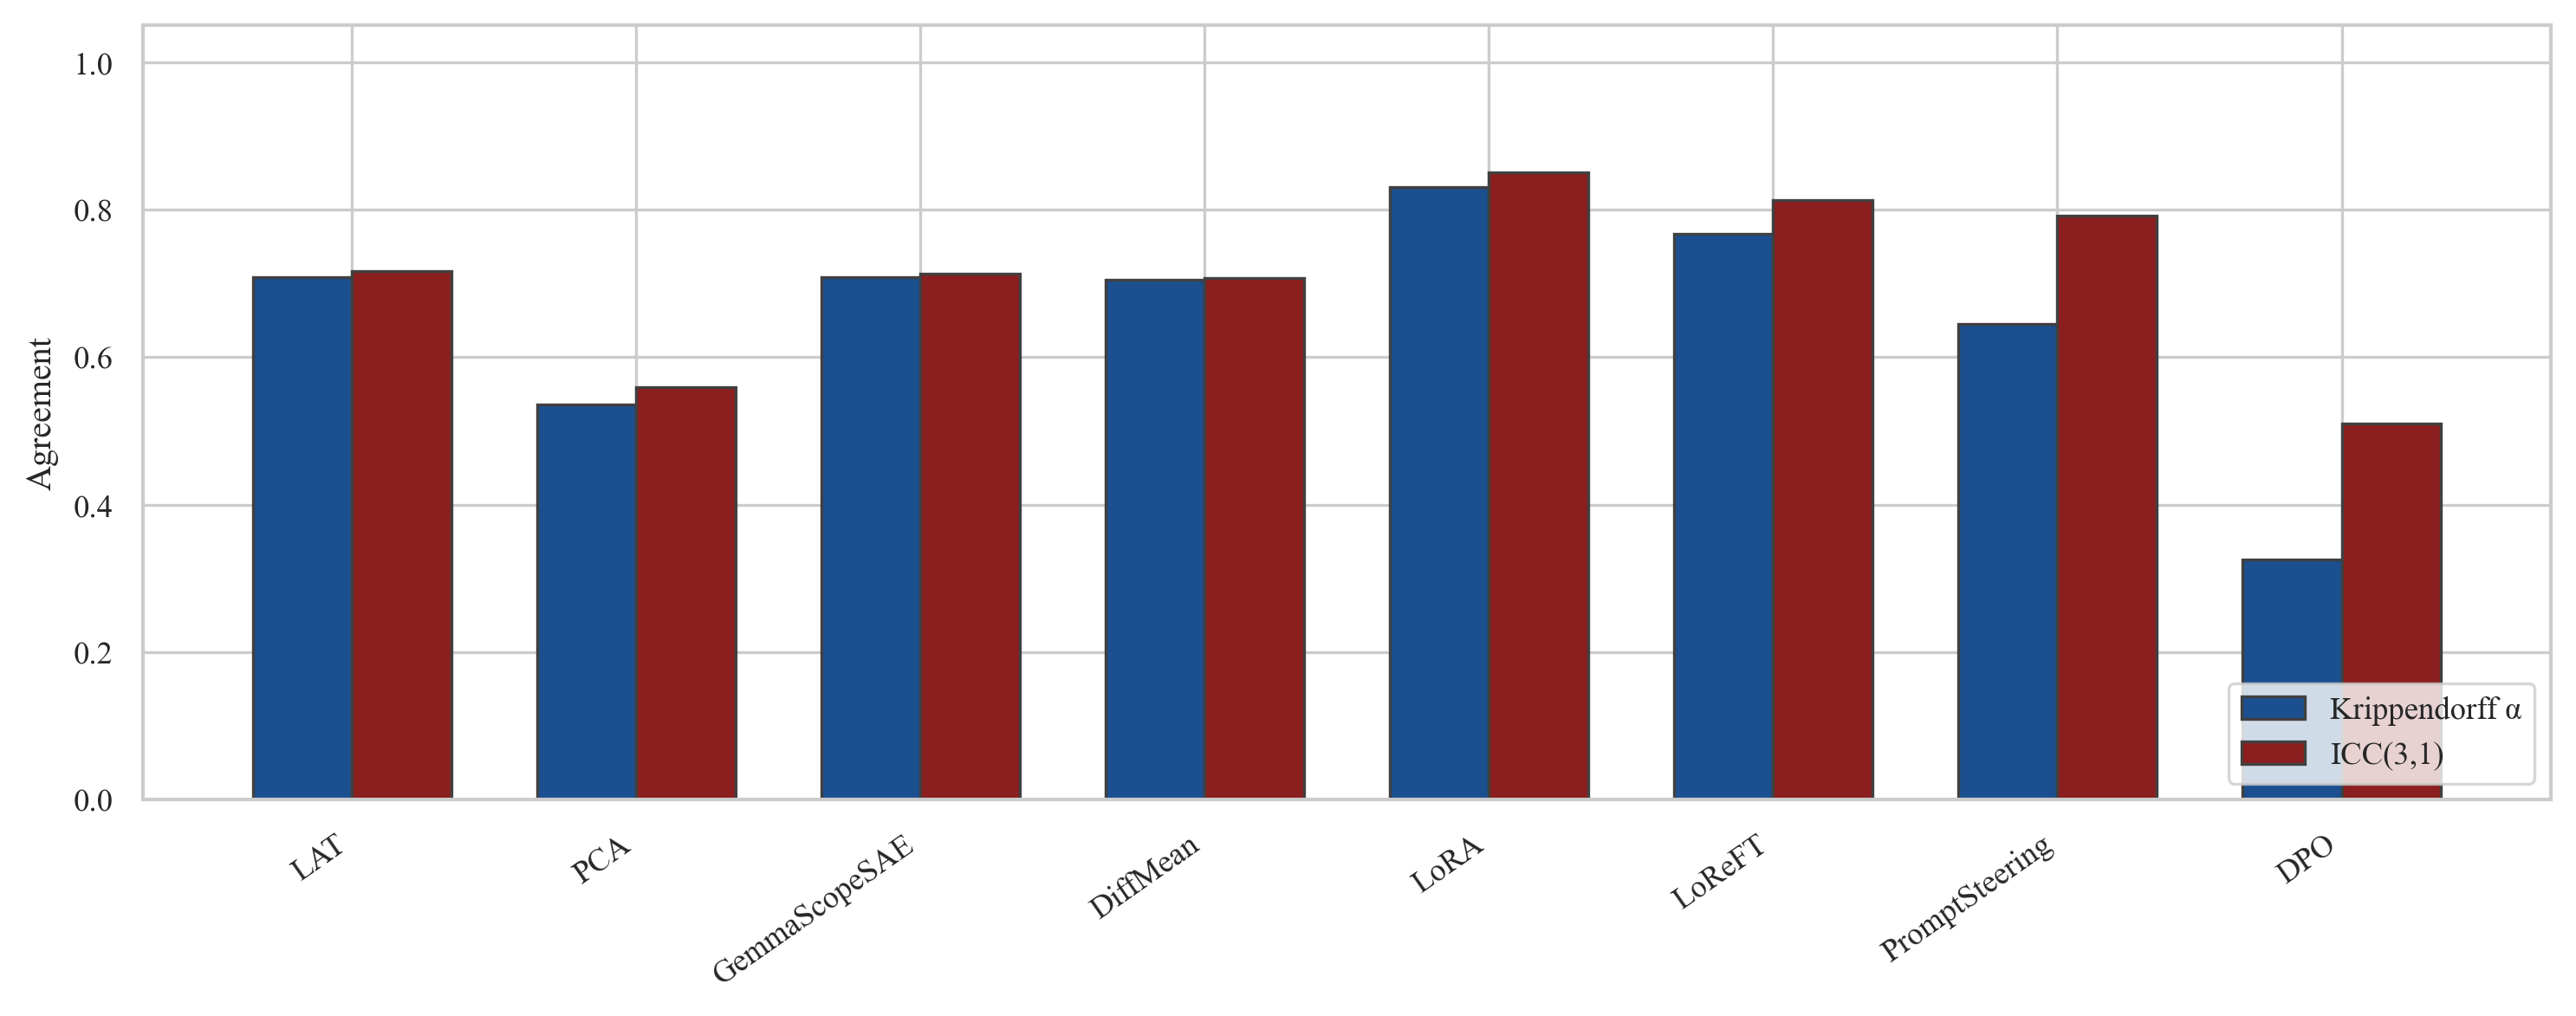

In [6]:
reliability_rows = []
for method in METHODS:
    wide = method_wide_scores(scores, method)
    reliability_rows.append(
        {
            "method": method,
            "krippendorff_alpha": krippendorff_alpha_ordinal(wide),
            "icc_3_1": icc_3_1_from_wide(wide),
        }
    )

reliability_df = pd.DataFrame(reliability_rows).set_index("method")

# Pooled over all method×item units (each unit has 3 judge scores)
pooled_wide = ratings_long.pivot(index="unit", columns="judge", values="score")[JUDGES]
pooled_alpha = krippendorff_alpha_ordinal(pooled_wide)
pooled_long = ratings_long.copy()
pooled_long["item"] = pooled_long["unit"]
pooled_icc = icc_3_1(pooled_long)

print("Per-method reliability (ordinal α, ICC(3,1) = ICC(C,1) in pingouin):")
display(reliability_df.round(3))
print(f"\nPooled over all {len(pooled_wide)} method×item units:")
print(f"  Krippendorff α = {pooled_alpha:.3f}")
print(f"  ICC(3,1)       = {pooled_icc:.3f}")

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(METHODS))
w = 0.35
ax.bar(
    x - w / 2,
    reliability_df["krippendorff_alpha"],
    w,
    label="Krippendorff α",
    color=METRIC_COLORS[0],
    edgecolor="0.25",
)
ax.bar(
    x + w / 2,
    reliability_df["icc_3_1"],
    w,
    label="ICC(3,1)",
    color=METRIC_COLORS[1],
    edgecolor="0.25",
)
ax.set_xticks(x, METHODS, rotation=35, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Agreement")
ax.legend(loc="lower right")
plt.tight_layout()
save_figure_pdf("fig01_reliability", fig=fig)
plt.show()

Macro-averaged pairwise agreement across methods:


,Anthropic,Google,OpenAI
Anthropic,1.000,0.711,0.664
Google,0.711,1.000,0.661
OpenAI,0.664,0.661,1.000


,Anthropic,Google,OpenAI
Anthropic,1.000,0.735,0.665
Google,0.735,1.000,0.708
OpenAI,0.665,0.708,1.000


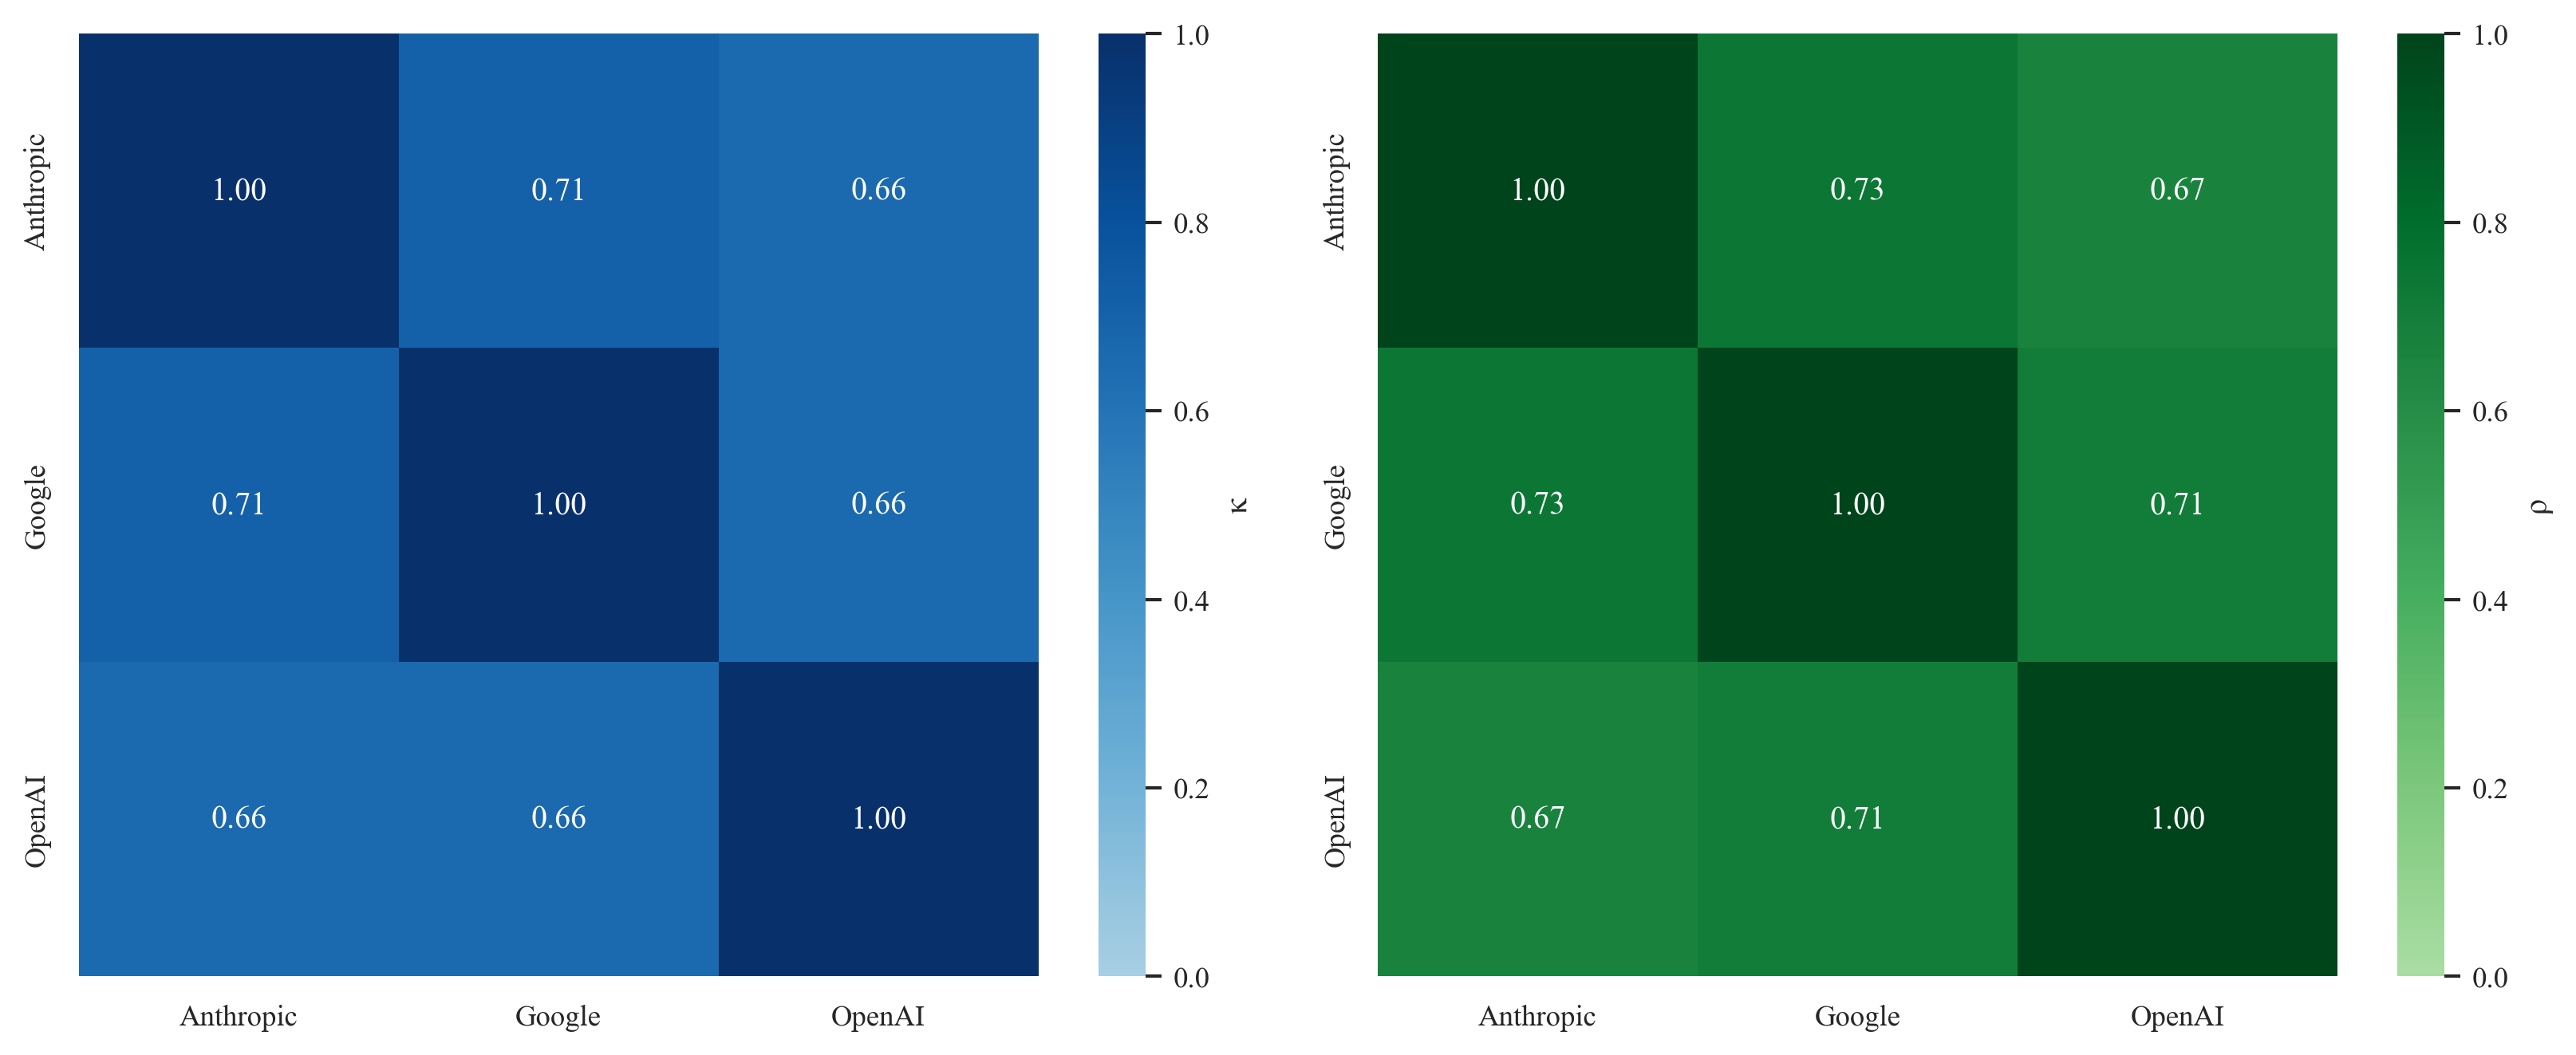

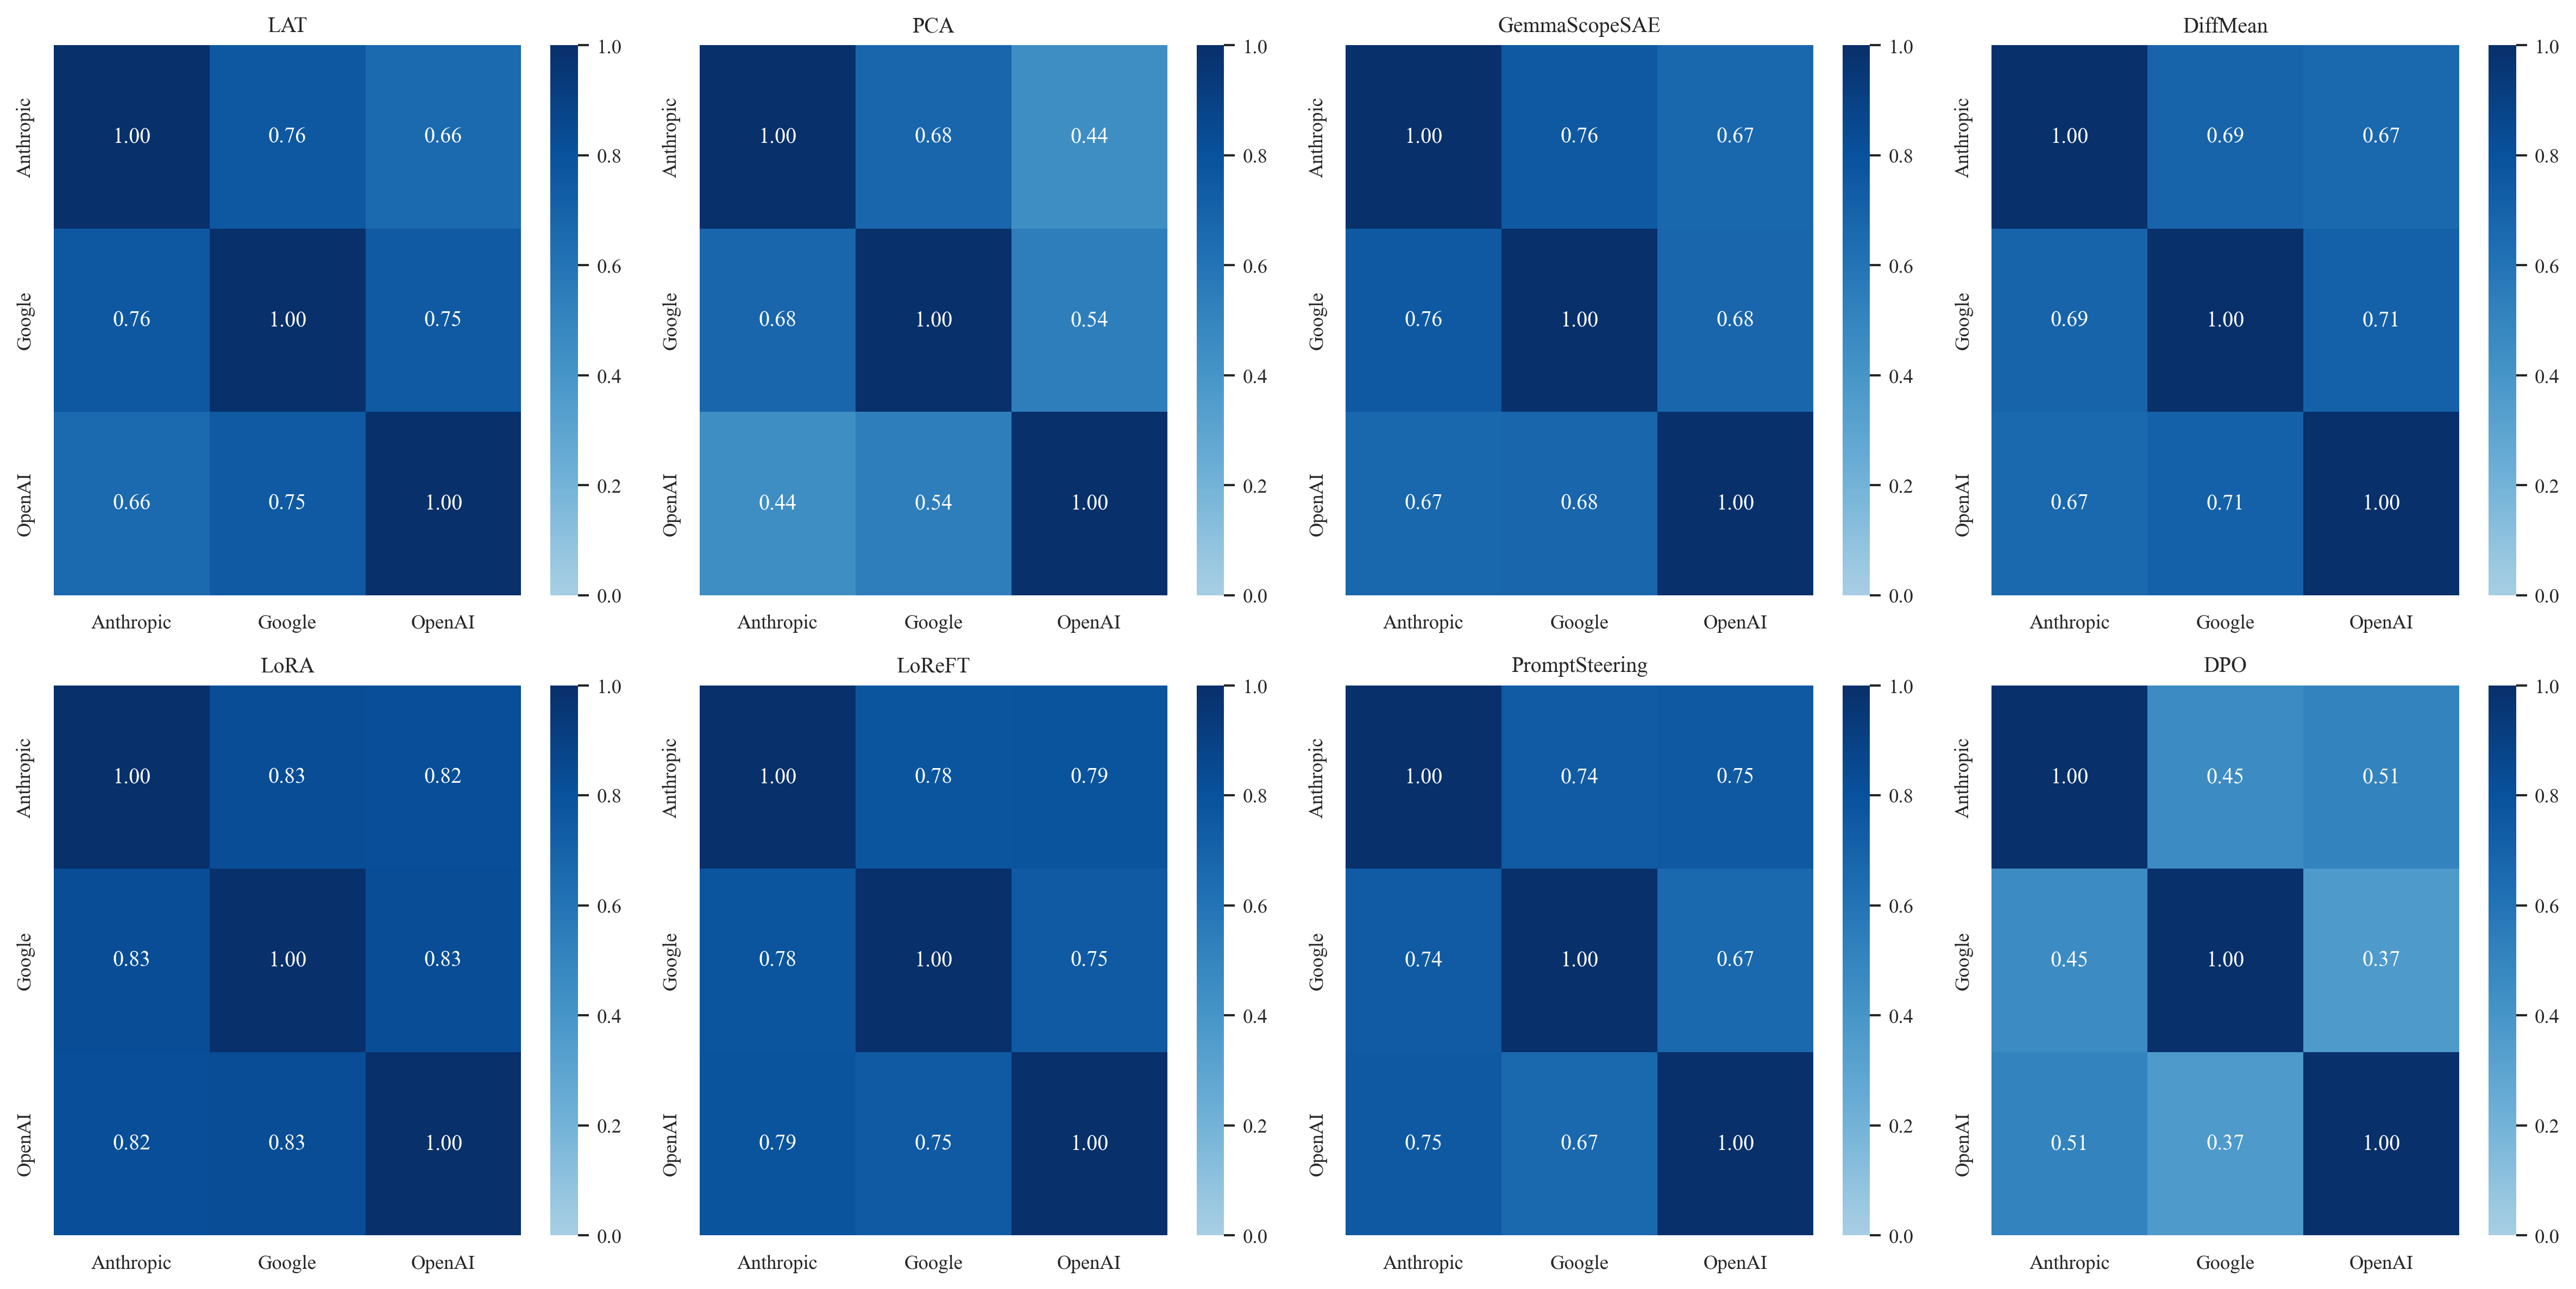

In [7]:
def pairwise_agreement(wide: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Weighted Cohen κ (ordinal bins) and Spearman ρ for each judge pair."""
    kappa = pd.DataFrame(np.nan, index=JUDGES, columns=JUDGES)
    spearman = pd.DataFrame(np.nan, index=JUDGES, columns=JUDGES)
    for j1, j2 in combinations(JUDGES, 2):
        o1, o2 = to_ordinal(wide[j1]), to_ordinal(wide[j2])
        k = cohen_kappa_score(o1, o2, weights="quadratic")
        rho, _ = spearmanr(wide[j1], wide[j2])
        kappa.loc[j1, j2] = kappa.loc[j2, j1] = k
        spearman.loc[j1, j2] = spearman.loc[j2, j1] = rho
    np.fill_diagonal(kappa.values, 1.0)
    np.fill_diagonal(spearman.values, 1.0)
    return kappa, spearman


# Average pairwise agreement across methods (macro-average)
kappa_mats, spearman_mats = [], []
for method in METHODS:
    k, s = pairwise_agreement(method_wide_scores(scores, method))
    kappa_mats.append(k)
    spearman_mats.append(s)

mean_kappa = sum(kappa_mats) / len(kappa_mats)
mean_spearman = sum(spearman_mats) / len(spearman_mats)

judge_labels = [JUDGE_LABELS[j] for j in JUDGES]
mean_kappa.index = mean_kappa.columns = judge_labels
mean_spearman.index = mean_spearman.columns = judge_labels

print("Macro-averaged pairwise agreement across methods:")
display(mean_kappa.round(3))
display(mean_spearman.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(
    mean_kappa,
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1,
    cmap=CMAP_KAPPA,
    ax=axes[0],
    cbar_kws={"label": "κ"},
)
sns.heatmap(
    mean_spearman,
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1,
    cmap=CMAP_SPEARMAN,
    ax=axes[1],
    cbar_kws={"label": "ρ"},
)
plt.tight_layout()
save_figure_pdf("fig02_pairwise_agreement", fig=fig)
plt.show()

# Optional: per-method κ heatmaps
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for ax, method, k_mat in zip(axes, METHODS, kappa_mats):
    k_plot = k_mat.copy()
    k_plot.index = k_plot.columns = judge_labels
    sns.heatmap(k_plot, annot=True, fmt=".2f", vmin=0, vmax=1, cmap=CMAP_KAPPA, ax=ax)
    ax.set_title(method)
if len(METHODS) < len(axes):
    axes[-1].axis("off")
plt.tight_layout()
save_figure_pdf("fig02b_pairwise_kappa_by_method", fig=fig)
plt.show()

## 2. Bias — judge scoring tendencies

Overall score distribution by judge:


,mean,std,median,count
judge,,,,
Anthropic,0.452,0.649,0.0,6720
Google,0.577,0.840,0.0,6720
OpenAI,0.397,0.614,0.0,6720


metric              mean                     std              
judge          Anthropic Google OpenAI Anthropic Google OpenAI
method                                                        
DPO                1.095  1.452  0.938     0.584  0.758  0.658
DiffMean           0.159  0.179  0.125     0.441  0.516  0.375
GemmaScopeSAE      0.139  0.163  0.108     0.416  0.487  0.349
LAT                0.086  0.077  0.058     0.328  0.346  0.257
LoRA               0.623  0.739  0.545     0.704  0.884  0.695
LoReFT             0.660  0.859  0.624     0.681  0.891  0.678
PCA                0.039  0.038  0.027     0.223  0.243  0.178
PromptSteering     0.815  1.113  0.748     0.662  0.885  0.619

/var/folders/dr/6dv3_zvd16sdmw4zwm1q5rxc0000gp/T/ipykernel_7615/2448664148.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([JUDGE_LABELS[j] for j in JUDGES])


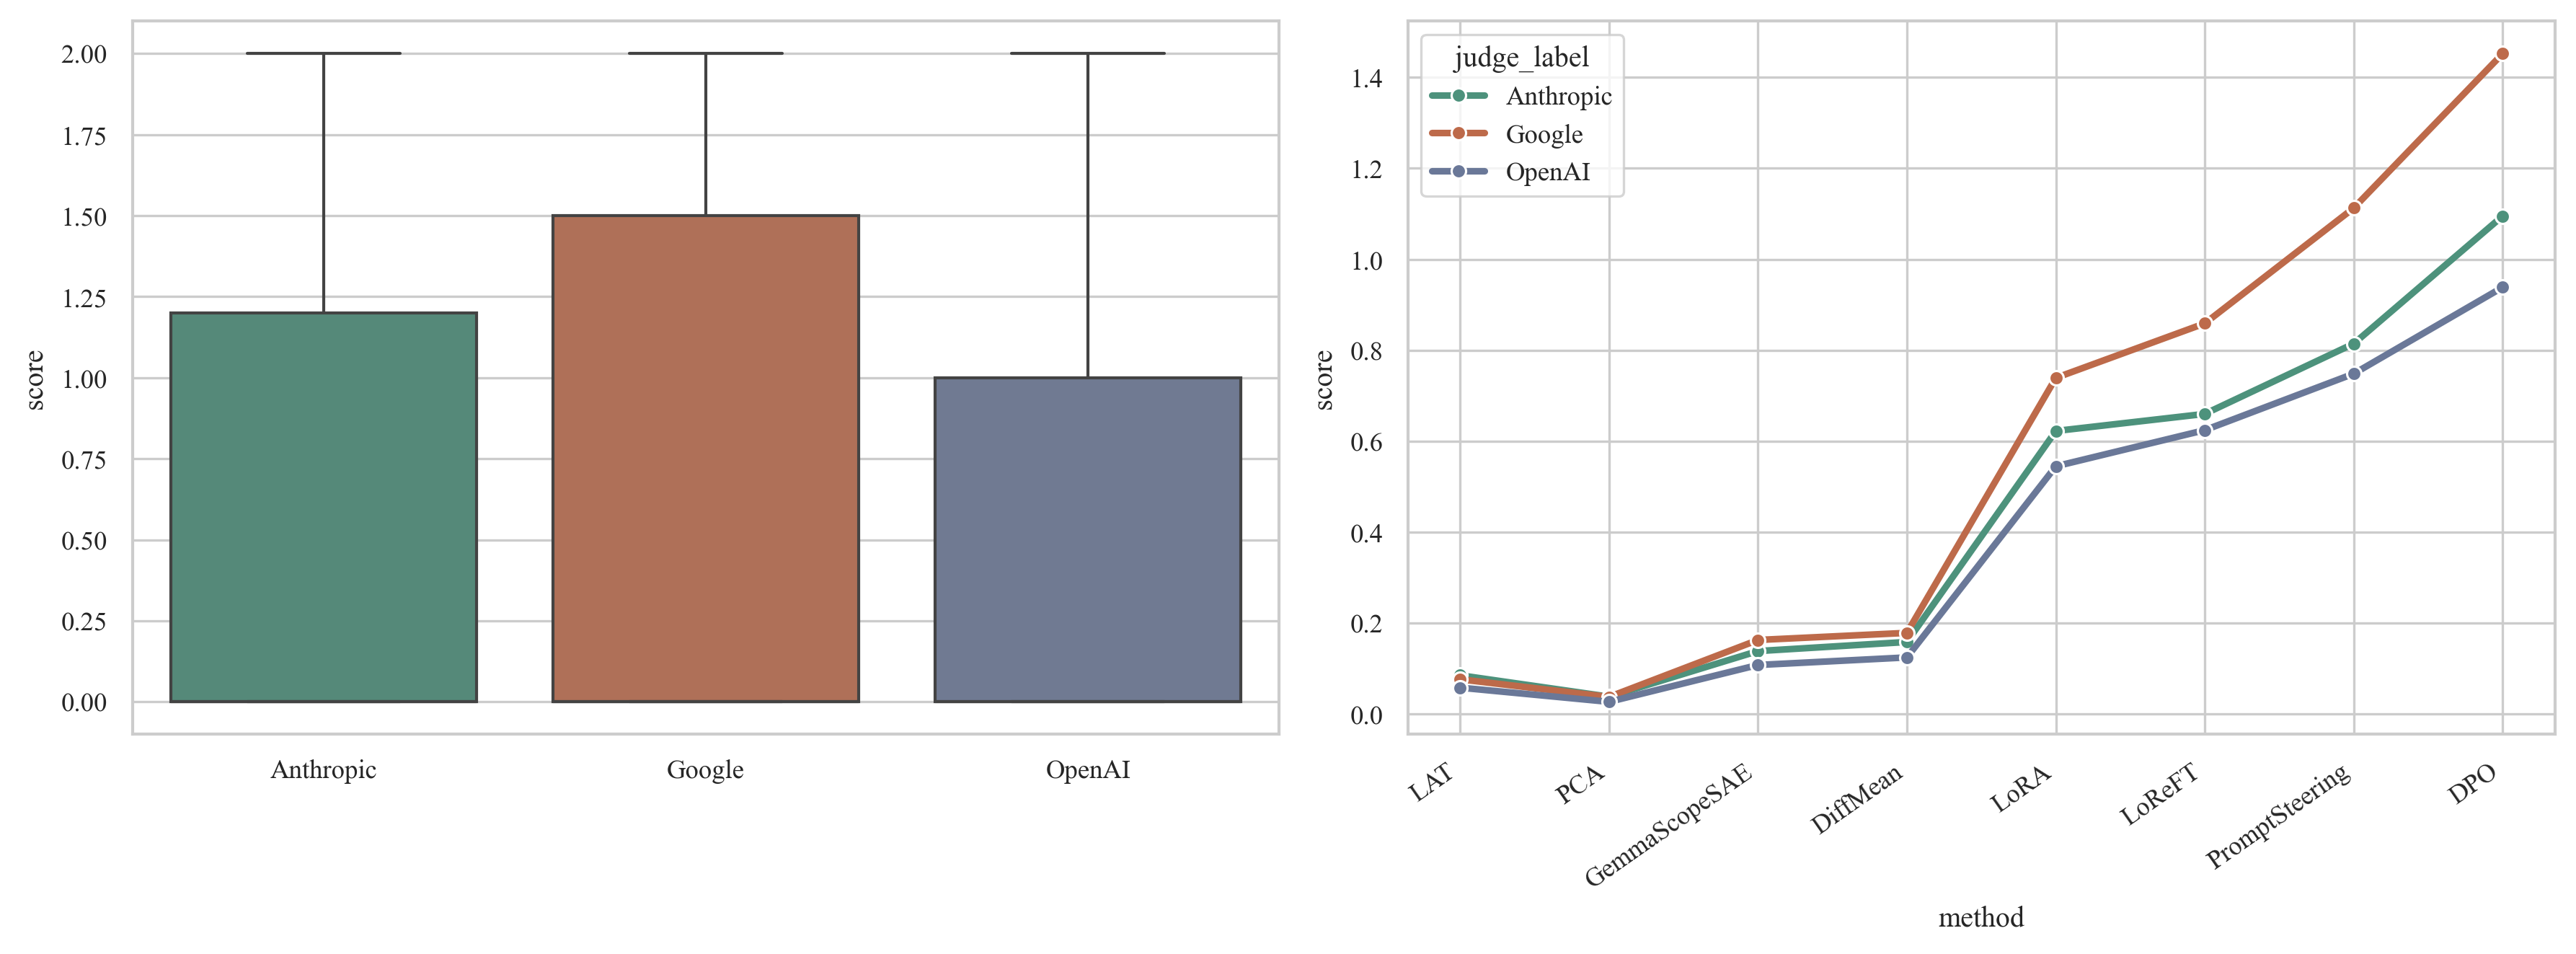

/opt/miniconda3/envs/intsteer/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


                            Mixed Linear Model Regression Results
Model:                         MixedLM             Dependent Variable:             score      
No. Observations:              20160               Method:                         REML       
No. Groups:                    840                 Scale:                          0.4269     
Min. group size:               24                  Log-Likelihood:                 -20726.2397
Max. group size:               24                  Converged:                      Yes        
Mean group size:               24.0                                                           
----------------------------------------------------------------------------------------------
                                                     Coef. Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------------
Intercept                                            0.397    0.012 32.205 0.00

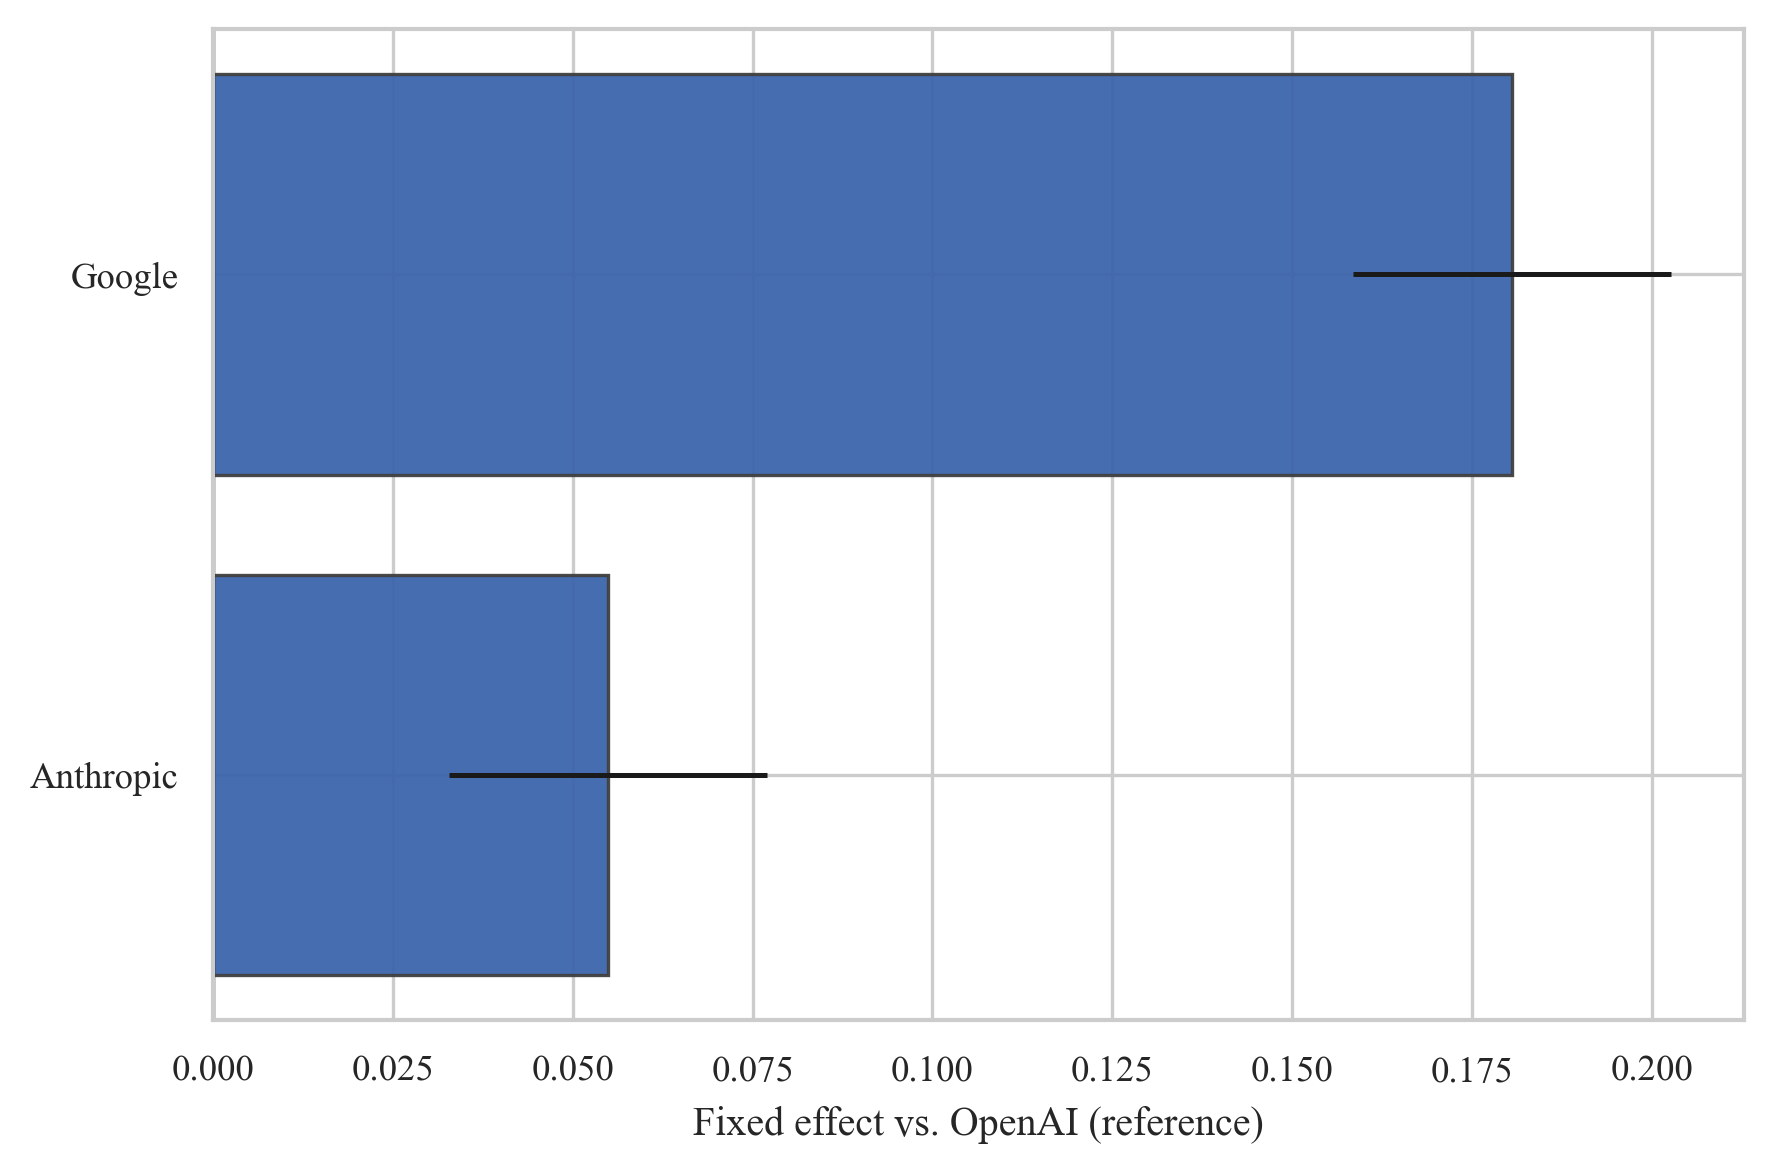

In [8]:
bias_stats = (
    ratings_long.groupby("judge")["score"]
    .agg(mean="mean", std="std", median="median", count="count")
    .rename(index=JUDGE_LABELS)
)
print("Overall score distribution by judge:")
display(bias_stats.round(3))

bias_by_method = (
    ratings_long.groupby(["method", "judge"])["score"]
    .agg(mean="mean", std="std")
    .unstack("judge")
)
# unstack after multi-metric agg → MultiIndex columns (metric, judge)
if isinstance(bias_by_method.columns, pd.MultiIndex):
    bias_by_method.columns = pd.MultiIndex.from_tuples(
        [(metric, JUDGE_LABELS[judge]) for metric, judge in bias_by_method.columns],
        names=["metric", "judge"],
    )
else:
    bias_by_method.columns = [JUDGE_LABELS[c] for c in bias_by_method.columns]
display(bias_by_method.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(
    data=ratings_long,
    x="judge",
    y="score",
    order=JUDGES,
    hue="judge",
    palette=JUDGE_PALETTE_LIST,
    legend=False,
    ax=axes[0],
)
axes[0].set_xticklabels([JUDGE_LABELS[j] for j in JUDGES])
axes[0].set_xlabel("")
means = ratings_long.groupby(["method", "judge"])["score"].mean().reset_index()
means["method"] = pd.Categorical(means["method"], categories=METHODS, ordered=True)
means["judge_label"] = means["judge"].map(JUDGE_LABELS)
means = means.sort_values("method")
# Numeric x avoids seaborn passing `order` to matplotlib Line2D (version-dependent bug)
means["method_idx"] = means["method"].cat.codes
sns.lineplot(
    data=means,
    x="method",
    y="score",
    hue="judge_label",
    hue_order=[JUDGE_LABELS[j] for j in JUDGES],
    palette=JUDGE_PALETTE_DISPLAY,
    marker="o",
    linewidth=2.2,
    ax=axes[1],
)
axes[1].set_xticks(range(len(METHODS)))
axes[1].set_xticklabels(METHODS, rotation=35, ha="right")
plt.tight_layout()
save_figure_pdf("fig03_judge_bias", fig=fig)
plt.show()

# Mixed-effects: random intercept per item, fixed judge effects
mixed_df = ratings_long.copy()
mixed_df["item_id"] = mixed_df["item"].astype(str)
mixed_model = smf.mixedlm(
    "score ~ C(judge, Treatment(reference='openai'))",
    mixed_df,
    groups=mixed_df["item_id"],
)
mixed_result = mixed_model.fit(reml=True, method="lbfgs")
print(mixed_result.summary())

def _judge_label(param_name: str) -> str:
    for j in JUDGES:
        if j in param_name:
            return JUDGE_LABELS[j]
    return param_name


judge_effects = mixed_result.params.filter(like="judge")
judge_effects.index = [_judge_label(n) for n in judge_effects.index]
judge_se = mixed_result.bse.filter(like="judge")
judge_se.index = judge_effects.index

fig, ax = plt.subplots(figsize=(6, 4))
y_pos = np.arange(len(judge_effects))
ax.barh(
    y_pos,
    judge_effects.values,
    xerr=1.96 * judge_se.values,
    color=BAR_COLOR,
    alpha=0.95,
    edgecolor="0.25",
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y_pos, judge_effects.index)
ax.set_xlabel("Fixed effect vs. OpenAI (reference)")
plt.tight_layout()
save_figure_pdf("fig03b_judge_effects", fig=fig)
plt.show()

## 3. Robustness — method rankings across judges

Mean method scores by judge:


,anthropic,google,openai
LAT,0.086,0.077,0.058
PCA,0.039,0.038,0.027
GemmaScopeSAE,0.139,0.163,0.108
DiffMean,0.159,0.179,0.125
LoRA,0.623,0.739,0.545
LoReFT,0.660,0.859,0.624
PromptSteering,0.815,1.113,0.748
DPO,1.095,1.452,0.938



Kendall's W (ranking consistency across judges): 1.000


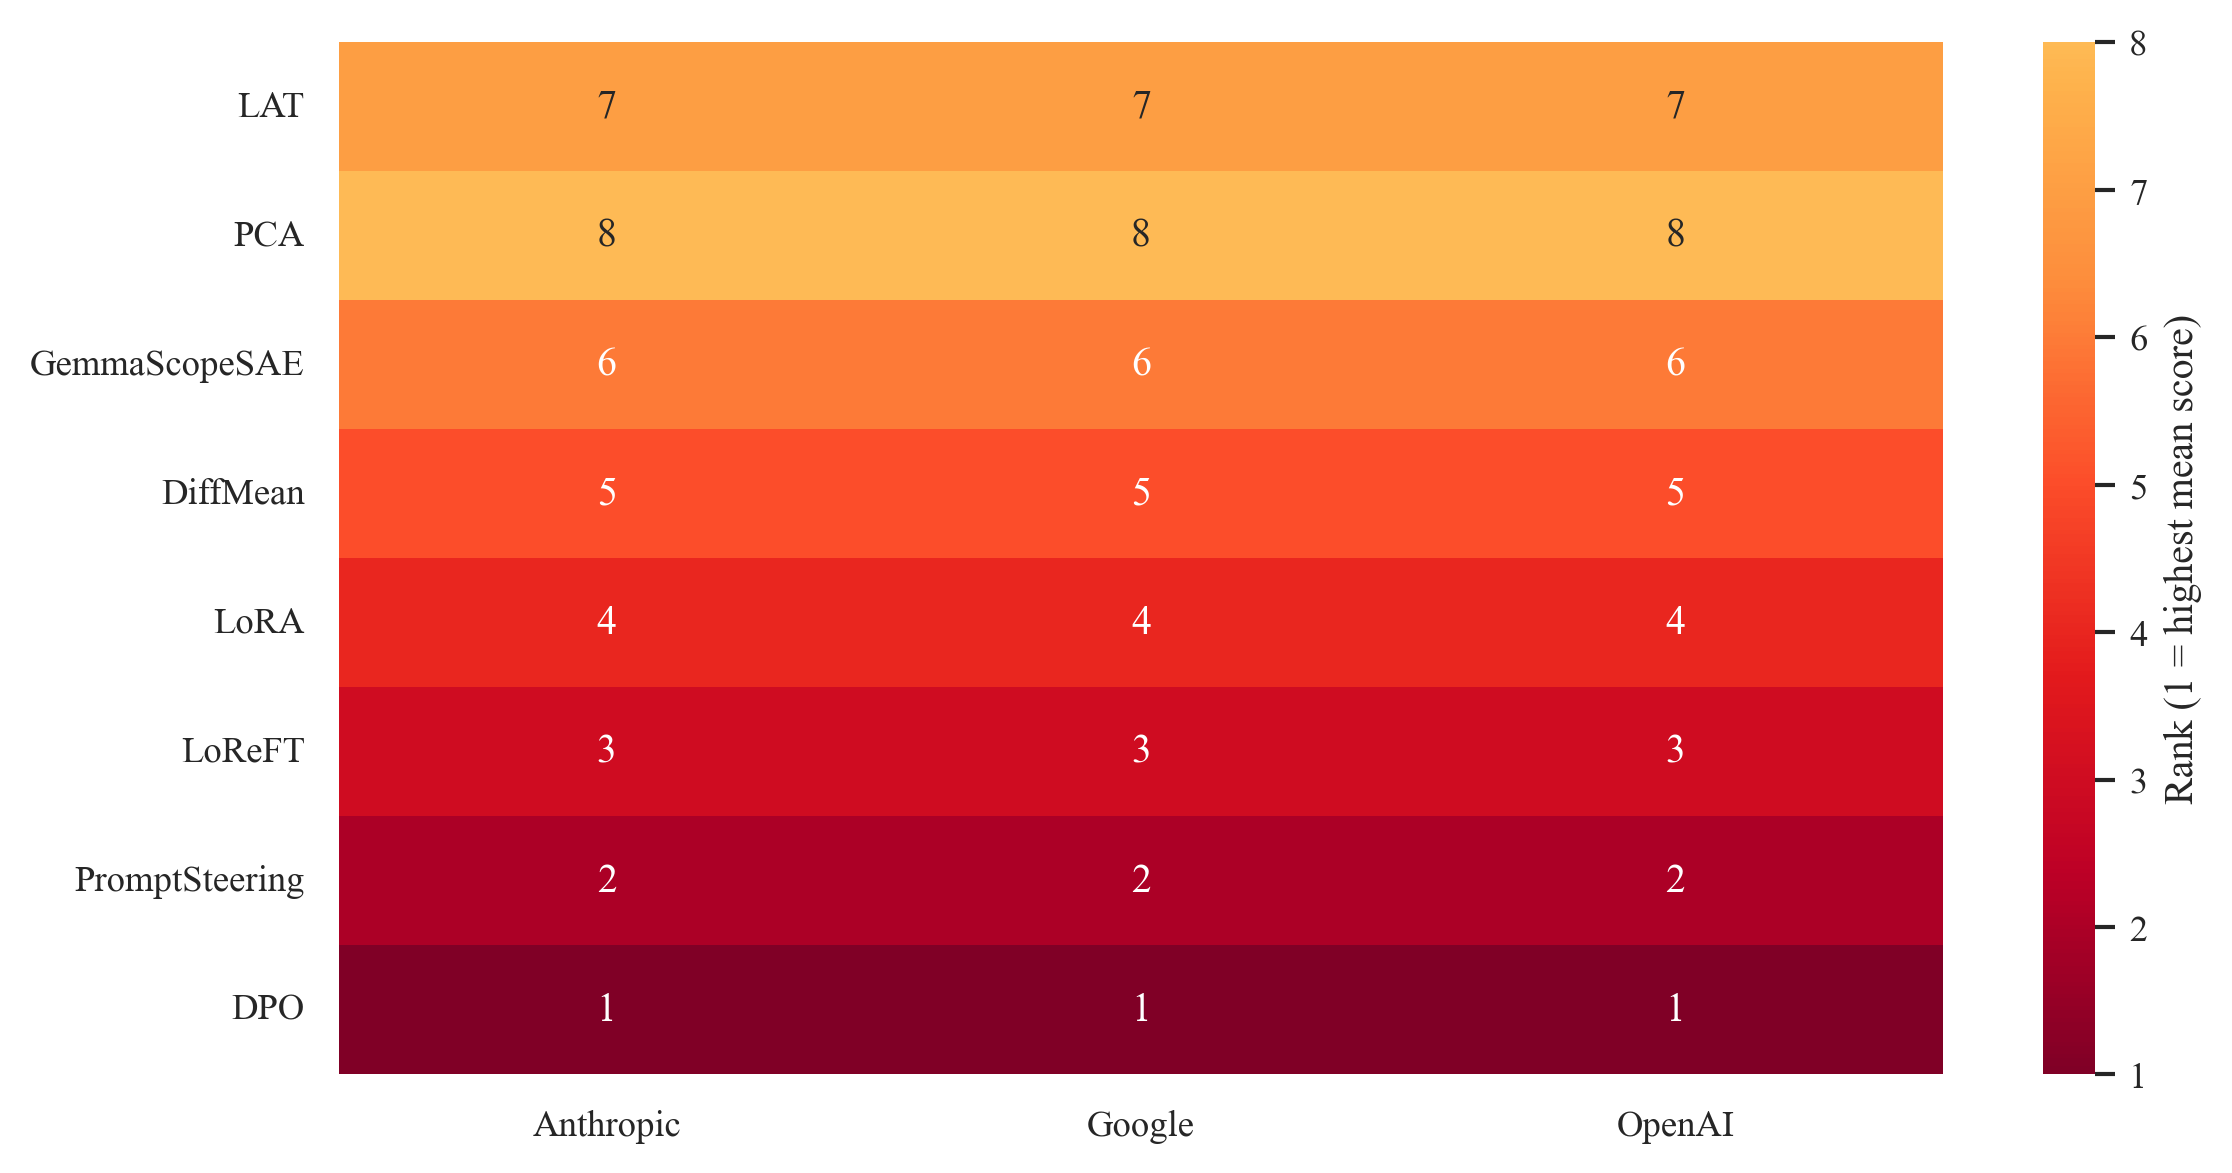

Leave-one-judge-out ranking stability (vs. 3-judge consensus):


,spearman_vs_full,p_value,top1_match
left_out,,,
Anthropic,1.0,0.0,True
Google,1.0,0.0,True
OpenAI,1.0,0.0,True


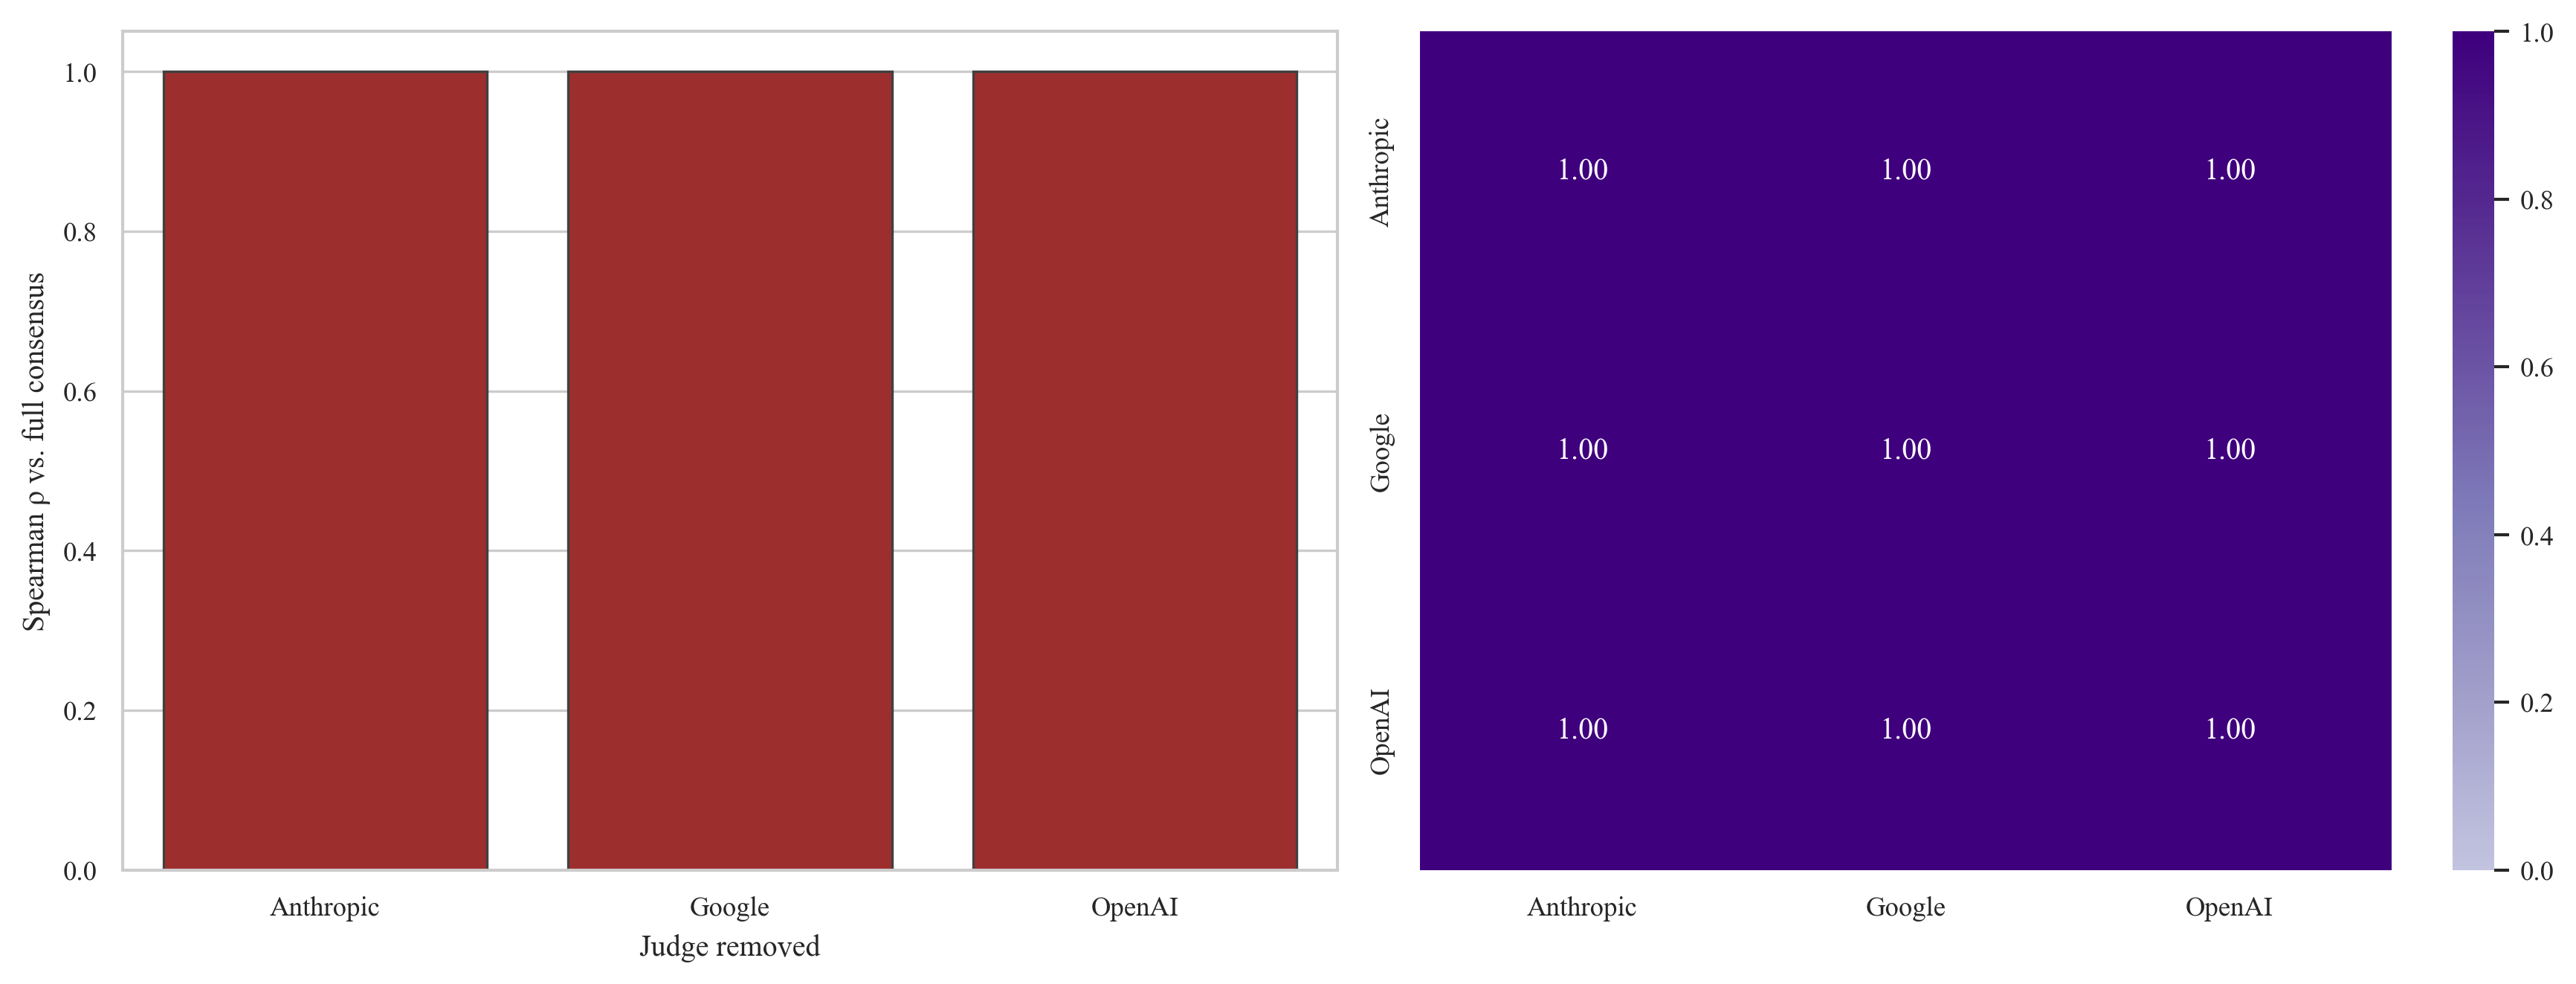

In [9]:
# Mean score per method for each judge → rank methods (1 = best)
method_means = pd.DataFrame(
    {
        j: {m: scores[score_col(m, j)].mean() for m in METHODS}
        for j in JUDGES
    }
)
method_ranks = method_means.rank(ascending=False, axis=0)

kendall_w_all = kendall_w(method_ranks)
print("Mean method scores by judge:")
display(method_means.round(3))
print(f"\nKendall's W (ranking consistency across judges): {kendall_w_all:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    method_ranks,
    annot=True,
    fmt=".0f",
    cmap=CMAP_RANK,
    ax=ax,
    cbar_kws={"label": "Rank (1 = highest mean score)"},
)
ax.set_xticklabels([JUDGE_LABELS[j] for j in method_ranks.columns])
plt.tight_layout()
save_figure_pdf("fig04_method_rankings", fig=fig)
plt.show()

# Leave-one-judge-out: compare consensus ranking with rankings from 2 judges
full_consensus = method_means.mean(axis=1).rank(ascending=False)

loo_rows = []
for left_out in JUDGES:
    keep = [j for j in JUDGES if j != left_out]
    loo_means = method_means[keep].mean(axis=1)
    loo_rank = loo_means.rank(ascending=False)
    rho, pval = spearmanr(full_consensus, loo_rank)
    loo_rows.append(
        {
            "left_out": JUDGE_LABELS[left_out],
            "spearman_vs_full": rho,
            "p_value": pval,
            "top1_match": loo_rank.idxmin() == full_consensus.idxmin(),
        }
    )

loo_df = pd.DataFrame(loo_rows).set_index("left_out")
print("Leave-one-judge-out ranking stability (vs. 3-judge consensus):")
display(loo_df.round(3))

# Rank correlation matrix: each judge's ranking vs. every other single-judge ranking
rank_corr = pd.DataFrame(np.nan, index=JUDGES, columns=JUDGES)
for j1 in JUDGES:
    r1 = method_means[j1].rank(ascending=False)
    for j2 in JUDGES:
        r2 = method_means[j2].rank(ascending=False)
        rank_corr.loc[j1, j2], _ = spearmanr(r1, r2)
rank_corr.index = rank_corr.columns = [JUDGE_LABELS[j] for j in JUDGES]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(
    data=loo_df.reset_index(),
    x="left_out",
    y="spearman_vs_full",
    ax=axes[0],
    color=ACCENT_COLOR,
    edgecolor="0.25",
)
axes[0].set_ylim(0, 1.05)
axes[0].set_xlabel("Judge removed")
axes[0].set_ylabel("Spearman ρ vs. full consensus")

sns.heatmap(
    rank_corr,
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1,
    cmap=CMAP_CORR,
    ax=axes[1],
)
plt.tight_layout()
save_figure_pdf("fig05_leave_one_out", fig=fig)
plt.show()

## Export tables for the paper

In [10]:
reliability_df.round(3).to_csv(TABLE_DIR / "reliability_by_method.csv")
mean_kappa.round(3).to_csv(TABLE_DIR / "pairwise_kappa_macro_avg.csv")
mean_spearman.round(3).to_csv(TABLE_DIR / "pairwise_spearman_macro_avg.csv")
bias_stats.round(3).to_csv(TABLE_DIR / "bias_judge_distributions.csv")
bias_by_method.round(3).to_csv(TABLE_DIR / "bias_by_method.csv")
method_means.round(3).to_csv(TABLE_DIR / "method_mean_scores_by_judge.csv")
method_ranks.to_csv(TABLE_DIR / "method_ranks_by_judge.csv")
loo_df.round(3).to_csv(TABLE_DIR / "leave_one_judge_out.csv")

summary = pd.DataFrame(
    {
        "metric": [
            "Krippendorff α (pooled)",
            "ICC(3,1) (pooled)",
            "Kendall W (method rankings)",
        ],
        "value": [pooled_alpha, pooled_icc, kendall_w_all],
    }
)
summary.to_csv(TABLE_DIR / "summary_metrics.csv", index=False)
print(f"Saved tables to {TABLE_DIR.resolve()}/")
print(f"Saved figure PDFs to {FIG_DIR.resolve()}/")
display(summary.round(3))

Saved tables to /Users/z5517269/Desktop/DPO-Steering/inter_rater_results/
Saved figure PDFs to /Users/z5517269/Desktop/DPO-Steering/figures/inter-rater/


,metric,value
0,Krippendorff α (pooled),0.814
1,"ICC(3,1) (pooled)",0.813
2,Kendall W (method rankings),1.000
